# Final Project

This is an ipynb file showing how to run the Speech Emotion Recognition project, there are two main files depending on a users preference demo.py for web rendering and main.py for running on a script

## Creating Ensemble Model Class

### CNN BiLSTM Class

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import librosa
import joblib

In [1]:
import torch.nn as nn
import torch.nn.functional as F

class CNNBiLSTM_Model(nn.Module):
    def __init__(self, num_classes, n_mels=64):
        super().__init__()
        
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
        )

        # After two 2x2 pools: n_mels / 4
        self.lstm_input_size = 64 * (n_mels // 4)

        self.lstm = nn.LSTM(
            input_size=self.lstm_input_size,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3,
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x: (B, 1, n_mels, T)
        x = self.cnn(x)
        B, C, H, T = x.shape
        x = x.permute(0, 3, 1, 2).contiguous()   # (B, T, C, H)
        x = x.view(B, T, C * H)                  # (B, T, C*H)
        out, _ = self.lstm(x)
        x = out[:, -1, :]
        return self.classifier(x)


The number of classes to predict are 6 (ANG, DIS, SAD, HAP, FEAR, NEU)

In [12]:
NUM_CLASSES = 6

Function that loads audio 

In [3]:
def load_audio(path, sr=16000):
        y, s = librosa.load(path, sr=sr, mono=True)
        return y, s

This function normalizes the peaks and removes white noise

In [4]:
def trim_and_normalize(y, top_db=30, target_dbfs=-1.0):
        yt, _ = librosa.effects.trim(y, top_db=top_db)
        peak = np.max(np.abs(yt)) + 1e-9
        scale = (10 ** (target_dbfs / 20.0)) / peak
        return yt * min(scale, 1.0)

This function returns the spectogram representation of the audio

In [5]:
def to_logmel(y, sr=16000, n_mels=64):
        S = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=n_mels,
            fmin=50,
            fmax=8000,
        )
        S_db = librosa.power_to_db(S, ref=np.max)
        return S_db.astype(np.float32)

This function loads the saved model from the training model

In [10]:
def load_cnn_model(path):
        model = CNNBiLSTM_Model(NUM_CLASSES, n_mels=64)
        state = torch.load(path, map_location=torch.device('cpu'))
        model.load_state_dict(state["state_dict"])
        return model

In [15]:
def predict_cnn(cnn_bilstm, audio_path):

        y, sr = load_audio(audio_path)
        y = trim_and_normalize(y)
        logmel = to_logmel(y, sr=sr)

        x = torch.from_numpy(logmel).unsqueeze(0).unsqueeze(0)

        with torch.no_grad():
            logits = cnn_bilstm(x)
            probs = F.softmax(logits, dim=-1)

        return probs

In [34]:
cnn_bilstm_model = load_cnn_model('models/cnn_bilstm_state.pt')
probs_cnn = predict_cnn(cnn_bilstm_model, 'demos/ransford_angry.wav')

Probablities predicted by CNN_BiLSTM

In [35]:
probs_cnn.shape

torch.Size([1, 6])

In [36]:
probs_cnn = probs_cnn.squeeze().numpy()
probs_cnn.shape

(6,)

### Wav2Vec Model

In [26]:
from transformers import Wav2Vec2Processor, Wav2Vec2Model
import joblib

In [27]:
def load_wav2vec2_model(path):
        logreg = joblib.load(path)
        processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
        w2v_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
        return logreg, processor, w2v_model

In [22]:
def predict_wav2vec(audio_path, processor, w2v_model, logreg):
        y, sr = librosa.load(audio_path, sr=16000)

        inputs = processor(y, sampling_rate=16000, return_tensors="pt")

        with torch.no_grad():
            outputs = w2v_model(**inputs)
            emb = outputs.last_hidden_state.mean(dim=1).numpy()

        probs = logreg.predict_proba(emb)[0]
        return probs

In [29]:
logreg, processor, w2v_model = load_wav2vec2_model('models/logreg_w2v.joblib')
probs = predict_wav2vec('demos/ransford_angry.wav', processor, w2v_model, logreg)

c:\Users\Nyamekye\anaconda3\envs\ece5831\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Nyamekye\anaconda3\envs\ece5831\Lib\site-packages\transformers\configuration_utils.py:306: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


In [31]:
probs.shape

(6,)

Great we are predicting in the same shape now to create the ensemble using alpha of 0.25

### Ensemble Prediction

We have convert from integer to label using this Dictionary

In [41]:
ID_2_LABEL = {
            0: "ANG",
            1: "DIS",
            2: "FEA",
            3: "HAP",
            4: "NEU",
            5: "SAD",
        }

In [43]:
def predict(audio_path, cnn_bilstm_model, processor, w2v_model, logreg, alpha=0.25):
        
        probs_cnn = predict_cnn(cnn_bilstm_model, audio_path).squeeze().numpy()
        probs_wav2vec = predict_wav2vec(audio_path, processor, w2v_model, logreg)

        print("CNN probs shape:", probs_cnn.shape)
        print("W2V probs shape:", probs_wav2vec.shape)

        if probs_cnn.shape != probs_wav2vec.shape:
            raise ValueError("Probability shapes do not match for ensemble.")
        
        final_probs = (1 - alpha) * probs_cnn + alpha * probs_wav2vec
        pred_id = final_probs.argmax()


        return {
            "label": ID_2_LABEL[pred_id],
            "probabilities": {
                ID_2_LABEL[i]: float(final_probs[i]) for i in range(NUM_CLASSES)
            }
        }

In [44]:
result = predict('demos/ransford_angry.wav', cnn_bilstm_model , processor, w2v_model, logreg)

CNN probs shape: (6,)
W2V probs shape: (6,)


Predicts an accurate label

In [45]:
result

{'label': 'ANG',
 'probabilities': {'ANG': 0.9544468673483243,
  'DIS': 0.00466008041343312,
  'FEA': 0.001476066908569121,
  'HAP': 0.038772181796915016,
  'NEU': 0.0004953574532304761,
  'SAD': 0.0001494161316864669}}

In [48]:
import matplotlib.pyplot as plt

In [46]:
def plot_probs(result):
        label = result["label"]
        probs = result["probabilities"]

        emotions = list(probs.keys())
        values = [probs[e] for e in emotions]

        fig, ax = plt.subplots()
        ax.bar(emotions, values)
        ax.set_title(f"Emotion probabilities (predicted: {label})")
        ax.set_xlabel("Emotion")
        ax.set_ylabel("Probability")
        ax.set_ylim(0, 1.0)

        return label, fig


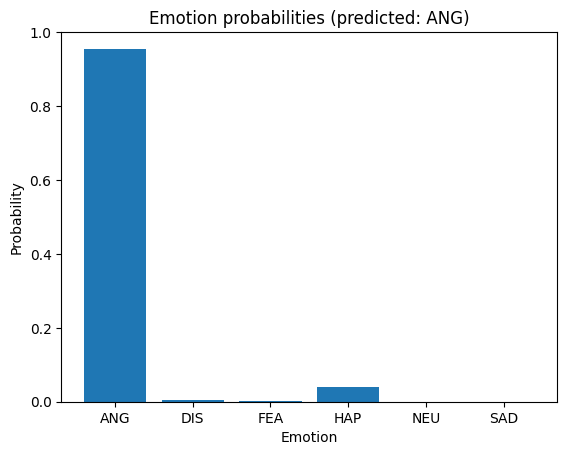

In [49]:
label, figure = plot_probs(result)

# Ensemble Model Class

In [50]:
import torch
import torch.nn.functional as F
import numpy as np
import librosa
import joblib
from transformers import Wav2Vec2Model
from CNNBiLSTM import CNNBiLSTM_Model
from transformers import Wav2Vec2Processor, Wav2Vec2Model
import gradio as gr
import matplotlib.pyplot as plt


class SpeechEmotionEnsembleModel:
    def __init__(self, cnn_bilstm_path, wav2vec2_path, num_classes=6):
        self.num_classes = num_classes
        logreg, processor, w2v_model = self.load_wav2vec2_model(wav2vec2_path)
        self.cnn_bilstm = self.load_cnn_model(cnn_bilstm_path)
        self.logreg = logreg
        self.processor = processor
        self.w2v_model = w2v_model
        
        self.ID_2_LABEL = {
            0: "ANG",
            1: "DIS",
            2: "FEA",
            3: "HAP",
            4: "NEU",
            5: "SAD",
        }


    def forward(self, x):
        out1 = self.model1(x)
        out2 = self.model2(x)
        out = (out1 + out2) / 2
        return out

    def load_audio(self, path, sr=16000):
        y, s = librosa.load(path, sr=sr, mono=True)
        return y, s


    def trim_and_normalize(self, y, top_db=30, target_dbfs=-1.0):
        yt, _ = librosa.effects.trim(y, top_db=top_db)
        peak = np.max(np.abs(yt)) + 1e-9
        scale = (10 ** (target_dbfs / 20.0)) / peak
        return yt * min(scale, 1.0)


    def to_logmel(self, y, sr=16000, n_mels=64):
        S = librosa.feature.melspectrogram(
            y=y,
            sr=sr,
            n_mels=n_mels,
            fmin=50,
            fmax=8000,
        )
        S_db = librosa.power_to_db(S, ref=np.max)
        return S_db.astype(np.float32)

    
    def load_cnn_model(self, path):
        model = CNNBiLSTM_Model(self.num_classes, n_mels=64)
        state = torch.load(path, map_location=torch.device('cpu'))
        model.load_state_dict(state["state_dict"])
        return model

    def predict_cnn(self, audio_path):

        y, sr = self.load_audio(audio_path)
        y = self.trim_and_normalize(y)
        logmel = self.to_logmel(y, sr=sr)

        x = torch.from_numpy(logmel).unsqueeze(0).unsqueeze(0)

        with torch.no_grad():
            logits = self.cnn_bilstm(x)
            probs = F.softmax(logits, dim=-1)

        return probs
    
    def load_wav2vec2_model(self, path):
        logreg = joblib.load(path)
        processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
        w2v_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
        return logreg, processor, w2v_model
    
    def predict_wav2vec(self, audio_path):
        y, sr = librosa.load(audio_path, sr=16000)

        inputs = self.processor(y, sampling_rate=16000, return_tensors="pt")

        with torch.no_grad():
            outputs = self.w2v_model(**inputs)
            emb = outputs.last_hidden_state.mean(dim=1).numpy()

        probs = self.logreg.predict_proba(emb)[0]
        return probs
    
    def predict(self, audio_path, alpha=0.25):
        
        probs_cnn = self.predict_cnn(audio_path).squeeze().numpy()
        probs_wav2vec = self.predict_wav2vec(audio_path)

        print("CNN probs shape:", probs_cnn.shape)
        print("W2V probs shape:", probs_wav2vec.shape)

        if probs_cnn.shape != probs_wav2vec.shape:
            raise ValueError("Probability shapes do not match for ensemble.")
        
        final_probs = (1 - alpha) * probs_cnn + alpha * probs_wav2vec
        pred_id = final_probs.argmax()


        return {
            "label": self.ID_2_LABEL[pred_id],
            "probabilities": {
                self.ID_2_LABEL[i]: float(final_probs[i]) for i in range(self.num_classes)
            }
        }

    def plot_probs(self, result):
        label = result["label"]
        probs = result["probabilities"]

        emotions = list(probs.keys())
        values = [probs[e] for e in emotions]

        fig, ax = plt.subplots()
        ax.bar(emotions, values)
        ax.set_title(f"Emotion probabilities (predicted: {label})")
        ax.set_xlabel("Emotion")
        ax.set_ylabel("Probability")
        ax.set_ylim(0, 1.0)

        return label, fig


In [51]:
predictor = SpeechEmotionEnsembleModel(
        "models/cnn_bilstm_state.pt",
        "models/logreg_w2v.joblib",
)

c:\Users\Nyamekye\anaconda3\envs\ece5831\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Nyamekye\anaconda3\envs\ece5831\Lib\site-packages\transformers\configuration_utils.py:306: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


CNN probs shape: (6,)
W2V probs shape: (6,)


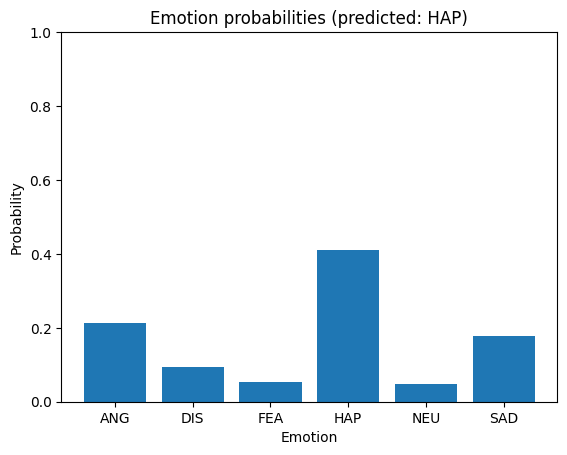

In [53]:
result = predictor.predict('demos/ransford_happy.wav')
label, fig = predictor.plot_probs(result)

# Testing with main.py

In [ ]:
import os
import glob
import subprocess
import sys

# test_all_demos_with_main.py
# Run this cell / script to test every demo file in the `demos/` folder
# by invoking main.py with the demo file as argument.
#
# It will call: python main.py <demo_path>
# If your main.py expects a different flag (for example --file_name <path>),
# change `use_flag=True` below.


DEMO_DIR = "demos"
MAIN_SCRIPT = "main.py"
USE_FLAG = False  # set True if main.py expects: --file_name <path>
TIMEOUT = 120  # seconds per demo run

# gather demo files by common audio extensions
exts = (".wav", ".mp3", ".flac", ".ogg", ".m4a")
demo_paths = sorted([p for p in glob.glob(os.path.join(DEMO_DIR, "*")) if p.lower().endswith(exts)])

if not demo_paths:
    print(f"No demo audio files found in {DEMO_DIR!r}.")
else:
    results = []
    for demo in demo_paths:
        print("=" * 80)
        print(f"Running main.py on: {demo}")
        if USE_FLAG:
            cmd = [sys.executable, MAIN_SCRIPT, "--file_name", demo]
        else:
            cmd = [sys.executable, MAIN_SCRIPT, demo]

        try:
            completed = subprocess.run(
                cmd,
                capture_output=True,
                text=True,
                timeout=TIMEOUT,
            )
        except subprocess.TimeoutExpired as e:
            print(f"TIMEOUT after {TIMEOUT}s for {demo}")
            results.append((demo, "timeout", None, None))
            continue

        print(f"Return code: {completed.returncode}")
        if completed.stdout:
            print("--- STDOUT ---")
            print(completed.stdout)
        if completed.stderr:
            print("--- STDERR ---")
            print(completed.stderr)

        status = "ok" if completed.returncode == 0 else "error"
        results.append((demo, status, completed.returncode, completed.stdout))

    # Summary
    print("\n" + "=" * 80)
    print("Summary")
    for demo, status, code, _ in results:
        print(f"{os.path.basename(demo):40s} -> {status} (code={code})")

Running main.py on: demos\dharsh_anger.wav
Return code: 0
--- STDOUT ---
True emotion: ANG
Predicted   : ANG
Correct     : YES

--- STDERR ---
c:\Users\Nyamekye\anaconda3\envs\ece5831\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Nyamekye\anaconda3\envs\ece5831\Lib\site-packages\transformers\configuration_utils.py:306: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(

Running main.py on: demos\dharsh_disgu